In [3]:
# Импорт необходимых библиотек
import os
import zipfile
import pandas as pd
import librosa
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [4]:
# Пути к файлам и директориям
DATA_DIR = ""
AUDIO_DIR = "/content/morse_dataset/morse_dataset"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")
SUBMISSION_CSV = os.path.join(DATA_DIR, "submission.csv")

In [5]:
# Загрузка обучающих данных
train_df = pd.read_csv(TRAIN_CSV)

# Параметры аудио
SR = 8000
N_MELS = 64
MAX_LEN = 256

In [6]:
train_df.head(10)

,id,message
0,1.opus,03ЩУЫЛПИГХ
1,2.opus,ЪЛТ0ДС6А3Г
2,3.opus,5ЭКЫБЗХЯН
3,4.opus,ЖЫЦОИ68КФ
4,5.opus,32Ю7МЫ ЗЛ
5,6.opus,7У98ШБ2
6,7.opus,УЗОЗ#Г8
7,8.opus,Ц Ж4 РЯХТЛ ВЕ
8,9.opus,ХЮЦ4ЙК5ГЦЯ С
9,10.opus,ЯЗЛ ЮОШЪЕ


In [7]:
# Функция для извлечения мел-спектрограммы
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SR)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    if mel_spec_db.shape[1] < MAX_LEN:
        pad_width = MAX_LEN - mel_spec_db.shape[1]
        mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mel_spec_db = mel_spec_db[:, :MAX_LEN]
    return mel_spec_db

In [8]:
# Токенизатор
class MorseTokenizer:
    def __init__(self):
        self.alphabet = sorted(list(set("".join(train_df['message'].values))))
        self.alphabet = ['<PAD>', '<SOS>', '<EOS>'] + self.alphabet
        self.char2idx = {ch: idx for idx, ch in enumerate(self.alphabet)}
        self.idx2char = {idx: ch for ch, idx in self.char2idx.items()}

    def encode(self, text):
        return [self.char2idx['<SOS>']] + [self.char2idx[c] for c in text] + [self.char2idx['<EOS>']]

    def decode(self, indices):
        return "".join([self.idx2char[i] for i in indices if i > 2])

    def vocab_size(self):
        return len(self.char2idx)

    def pad_token_id(self):
        return self.char2idx['<PAD>']

In [91]:
# Инициализация токенизатора
tokenizer = MorseTokenizer()

In [92]:
# Dataset
class MorseDataset(Dataset):
    def __init__(self, dataframe, audio_dir, tokenizer):
        self.dataframe = dataframe
        self.audio_dir = audio_dir
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        file_path = os.path.join(self.audio_dir, str(row['id']))
        features = extract_features(file_path)
        label = self.tokenizer.encode(row['message'])
        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


In [93]:
def collate_fn(batch):
    specs, labels = zip(*batch)
    specs = torch.stack(specs)
    labels = pad_sequence(labels, batch_first=True, padding_value=tokenizer.pad_token_id())
    return specs, labels

train_dataset = MorseDataset(train_df, AUDIO_DIR, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

In [94]:
train_dataset = MorseDataset(train_df, AUDIO_DIR, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

In [95]:
class MorseNet(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 2))
        )
        self.lstm = nn.LSTM(input_size=64 * (N_MELS // 4), hidden_size=128, num_layers=2, batch_first=True, bidirectional=True)
        self.classifier = nn.Linear(128 * 2, vocab_size)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(x.size(0), x.size(1), -1)
        x, _ = self.lstm(x)
        logits = self.classifier(x)
        return logits

In [96]:
model = MorseNet(tokenizer.vocab_size())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id())

In [97]:
def train(model, loader, optimizer, criterion, epochs=20):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            logits = logits.view(-1, logits.size(-1))
            y = y.view(-1)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Эпоха {epoch+1}/{epochs}, Потери: {total_loss/len(loader):.4f}")

In [98]:
# ===== Инференс и декодирование =====
def infer(model, file_path):
    model.eval()
    with torch.no_grad():
        x = extract_features(file_path)
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().tolist()
        text = tokenizer.decode(preds)
    return text

In [99]:
# ===== Предсказания на тесте и сохранение =====
def predict_and_save(model, test_csv_path, audio_dir, output_path):
    test_df = pd.read_csv(test_csv_path)
    predictions = []
    for fname in test_df['id']:
        fpath = os.path.join(audio_dir, str(fname))
        pred = infer(model, fpath)
        predictions.append((fname, pred))
    sub = pd.DataFrame(predictions, columns=['id', 'message'])
    sub.to_csv(output_path, index=False)
    print("Готово! Сохранено в:", output_path)

In [100]:
predict_and_save(model, TEST_CSV, AUDIO_DIR, SUBMISSION_CSV)

Готово! Сохранено в: submission.csv


In [30]:
test_df = pd.read_csv('test.csv')

In [31]:
test_df

,id
0,30001.opus
1,30002.opus
2,30003.opus
3,30004.opus
4,30005.opus
...,...
4995,34996.opus
4996,34997.opus
4997,34998.opus
4998,34999.opus


In [62]:
!unzip -q /content/morse_dataset.zip -d /content/morse_dataset

In [65]:
import os
print(os.listdir("/content/morse_dataset/morse_dataset")[:10])


['14299.opus', '29973.opus', '7942.opus', '1089.opus', '7871.opus', '33377.opus', '32256.opus', '9842.opus', '10215.opus', '26115.opus']


In [101]:
sub = pd.read_csv("submission.csv")

In [102]:
sub

,id,message
0,30001.opus,Г5555555В555555555555555555555ГГАЫЫЫ ...
1,30002.opus,5555555555555555555555555555ЯЯЯЫЫЫЫЫЫ ...
2,30003.opus,555555555555555555ЯЯЯЯЯЯЯЯЯЯЯММААЫЫЫЫ ...
3,30004.opus,555555555555555ГГГ5555555ГГГГГГГГГГЫЫ ...
4,30005.opus,ГЙЙЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯЯГАА00000 ...
...,...,...
4995,34996.opus,ГГГГГГГГГГГГГГГГГГГГГГГГГГГГ5ГГ55ГГГГ55ГГГ5Г5Г...
4996,34997.opus,БГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГГ...
4997,34998.opus,ГВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВ...
4998,34999.opus,ВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВВ...




---



# **По новой**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import torch
from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio

# Убедимся, что GPU доступен
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥 Используемое устройство: {device}")

🖥 Используемое устройство: cpu


In [2]:
# Пути к CSV-файлам
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

# Посмотрим на данные
print("👀 Пример из train:")
display(train_df.head())

print("\n📊 Общая информация:")
print(train_df.info())

print("\n📝 Пример из test:")
display(test_df.head())

👀 Пример из train:


,id,message
0,1.opus,03ЩУЫЛПИГХ
1,2.opus,ЪЛТ0ДС6А3Г
2,3.opus,5ЭКЫБЗХЯН
3,4.opus,ЖЫЦОИ68КФ
4,5.opus,32Ю7МЫ ЗЛ



📊 Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       30000 non-null  object
 1   message  30000 non-null  object
dtypes: object(2)
memory usage: 468.9+ KB
None

📝 Пример из test:


,id
0,30001.opus
1,30002.opus
2,30003.opus
3,30004.opus
4,30005.opus


In [3]:
example = pd.read_csv("sample_submission.csv")
example

,id,message
0,30001.opus,А
1,30002.opus,А
2,30003.opus,А
3,30004.opus,А
4,30005.opus,А
...,...,...
4995,34996.opus,А
4996,34997.opus,А
4997,34998.opus,А
4998,34999.opus,А


In [11]:
# Обновим путь к директории с аудио
AUDIO_DIR = "morse_dataset/"

# Пример: загрузим 1-й файл из train
filename = train_df.iloc[-1]["id"]  # например, "1.opus"
filepath = AUDIO_DIR + filename

# Загружаем аудио с помощью torchaudio
waveform, sample_rate = torchaudio.load(filepath)
print(f"✔ Загружено: {filename}")
print(f"→ Waveform shape: {waveform.shape}")
print(f"→ Sample rate: {sample_rate} Гц")


✔ Загружено: 30000.opus
→ Waveform shape: torch.Size([1, 64000])
→ Sample rate: 8000 Гц


In [12]:
Audio(waveform.numpy(), rate=sample_rate)


In [17]:
import torchaudio
from IPython.display import Audio

for i in range(2, 18):
    # Загружаем OPUS-файл
    AUDIO_DIR = "morse_dataset/"
    # Пример: загрузим 1-й файл из train
    filename = train_df.iloc[-i]["id"]  # например, "1.opus"
    filepath = os.path.join(AUDIO_DIR, filename)
    waveform, sample_rate = torchaudio.load(filepath)
    
    # Сохраняем как WAV
    torchaudio.save(f"{18 - i}.wav", waveform, sample_rate)
    
    # Выводим форму и частоту дискретизации
    print(f"Waveform shape: {waveform.shape}")
    print(f"Sample rate: {sample_rate}")
    
    # Воспроизводим звук
    Audio(waveform.numpy(), rate=sample_rate)


Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000
Waveform shape: torch.Size([1, 64000])
Sample rate: 8000


C:\Users\Admin\Desktop\Код\Питон\morse\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


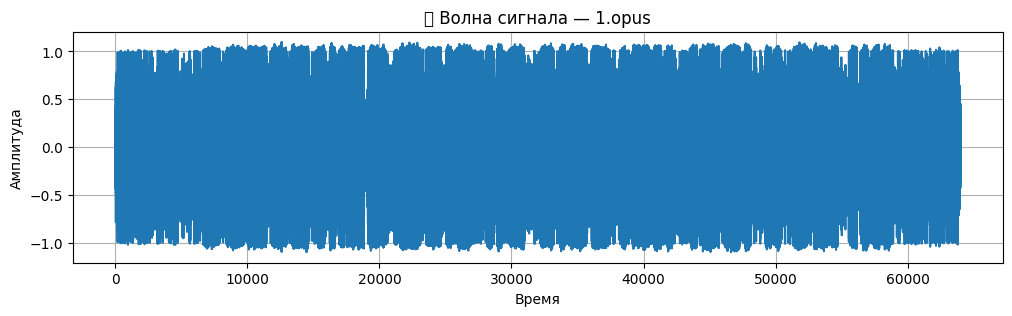

In [9]:
plt.figure(figsize=(12, 3))
plt.plot(waveform.t().numpy())
plt.title(f"🔊 Волна сигнала — {filename}")
plt.xlabel("Время")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()


C:\Users\Admin\Desktop\Код\Питон\morse\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


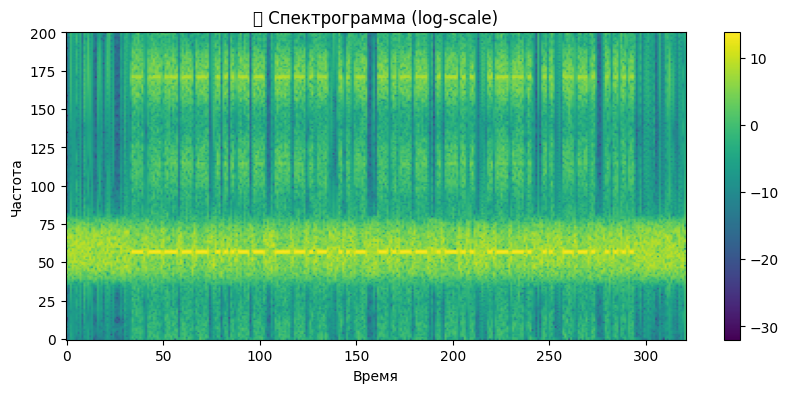

In [10]:
spec = torchaudio.transforms.Spectrogram()(waveform)
plt.figure(figsize=(10, 4))
plt.imshow(spec.log2()[0,:,:].numpy(), aspect='auto', origin='lower')
plt.title("📡 Спектрограмма (log-scale)")
plt.xlabel("Время")
plt.ylabel("Частота")
plt.colorbar()
plt.show()


In [8]:
class MorseDataset(Dataset):
    def __init__(self, df, audio_dir, sample_rate=48000, n_mels=64, transform=None):
        self.df = df
        self.audio_dir = audio_dir
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.transform = transform

        # Преобразование аудио в мел-спектрограмму
        self.mel_extractor = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate,
            n_fft=1024,
            hop_length=512,
            n_mels=self.n_mels
        )
        self.db_transform = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id"]
        filepath = os.path.join(self.audio_dir, filename)

        # Загрузка аудио
        waveform, sr = torchaudio.load(filepath)

        # Преобразование в Mel Spectrogram
        mel_spec = self.mel_extractor(waveform)
        mel_spec_db = self.db_transform(mel_spec)

        # Нормализация (опционально — но помогает модели)
        mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-6)

        # Выход: [1, n_mels, time]
        mel_spec_db = mel_spec_db.squeeze(0)  # -> [n_mels, time]

        # Возвращаем: признаки + целевой текст
        return mel_spec_db, row["message"]


🎧 Mel features shape: torch.Size([64, 751])
📝 Метка: 03ЩУЫЛПИГХ


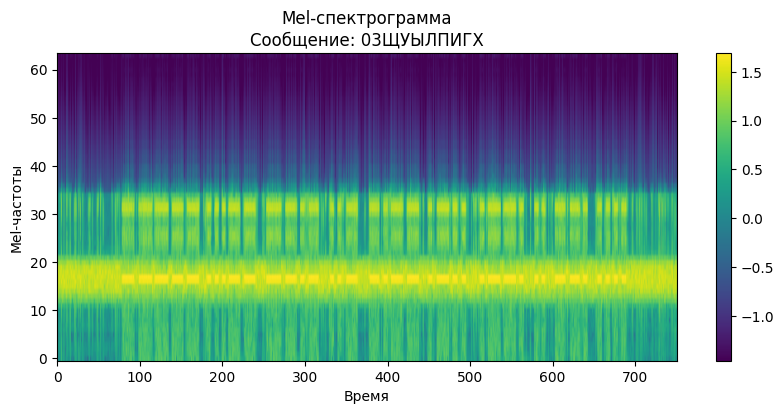

In [9]:
dataset = MorseDataset(train_df, AUDIO_DIR)

# Протестируем 1-й элемент
features, label = dataset[0]
print(f"🎧 Mel features shape: {features.shape}")  # [n_mels, time]
print(f"📝 Метка: {label}")

# Визуализируем спектрограмму
plt.figure(figsize=(10, 4))
plt.imshow(features.numpy(), aspect='auto', origin='lower')
plt.title(f"Mel-спектрограмма\nСообщение: {label}")
plt.xlabel("Время")
plt.ylabel("Mel-частоты")
plt.colorbar()
plt.show()


In [10]:
# Собираем алфавит из всех символов train
all_text = "".join(train_df["message"].values)
vocab = sorted(set(all_text))

# Создаем маппинг символов в индексы
char2idx = {c: i + 1 for i, c in enumerate(vocab)}  # 0 — для padding
idx2char = {i: c for c, i in char2idx.items()}

print(f"🔠 Алфавит ({len(vocab)} символов): {vocab}")


🔠 Алфавит (44 символов): [' ', '#', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ъ', 'Ы', 'Ь', 'Э', 'Ю', 'Я']


In [11]:
def text_to_int_sequence(text):
    return [char2idx[c] for c in text]

def int_sequence_to_text(seq):
    return "".join([idx2char[i] for i in seq if i != 0])


In [12]:
original = train_df.iloc[0]["message"]
encoded = text_to_int_sequence(original)
decoded = int_sequence_to_text(encoded)

print(f"🔤 Исходный текст: {original}")
print(f"🔢 Закодировано: {encoded}")
print(f"🔁 Раскодировано: {decoded}")


🔤 Исходный текст: 03ЩУЫЛПИГХ
🔢 Закодировано: [3, 6, 38, 32, 40, 24, 28, 21, 16, 34]
🔁 Раскодировано: 03ЩУЫЛПИГХ


In [13]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    specs = []
    labels = []
    input_lengths = []
    label_lengths = []

    for mel, text in batch:
        specs.append(mel.T)  # [time, n_mels]
        label_seq = torch.tensor(text_to_int_sequence(text), dtype=torch.long)
        labels.append(label_seq)

        input_lengths.append(mel.shape[1])  # time-steps
        label_lengths.append(len(label_seq))

    # Паддинг по time (ширине)
    specs_padded = pad_sequence(specs, batch_first=True)  # [batch, time, n_mels]
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=0)  # [batch, label_len]

    return {
        "inputs": specs_padded.permute(0, 2, 1),  # -> [batch, n_mels, time]
        "labels": labels_padded,
        "input_lengths": torch.tensor(input_lengths),
        "label_lengths": torch.tensor(label_lengths),
    }


In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)


In [15]:
batch = next(iter(train_loader))
print("🎛 Формат батча:")
for k, v in batch.items():
    print(f"{k}: {v.shape}")


🎛 Формат батча:
inputs: torch.Size([8, 64, 751])
labels: torch.Size([8, 12])
input_lengths: torch.Size([8])
label_lengths: torch.Size([8])


In [16]:
import torch.nn as nn
import torch.nn.functional as F

class CRNNModel(nn.Module):
    def __init__(self, num_classes, n_mels=64, hidden_size=128, num_layers=2):
        super(CRNNModel, self).__init__()

        # CNN блок — свёртка по "высоте" спектрограммы
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # [B, 1, n_mels, T] → [B, 32, n_mels, T]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),  # уменьшаем по частотам, не по времени
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 1))  # итог: n_mels → n_mels//4
        )

        # BiLSTM — обрабатывает последовательность по времени
        self.lstm = nn.LSTM(
            input_size=(n_mels // 4) * 64,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True
        )

        # Финальный классификатор
        self.classifier = nn.Linear(hidden_size * 2, num_classes + 1)  # +1 для CTC blank

    def forward(self, x):  # x: [B, 1, n_mels, T]
        x = self.cnn(x)  # → [B, 64, n_mels//4, T]
        b, c, h, t = x.size()
        x = x.permute(0, 3, 1, 2)  # → [B, T, C, H]
        x = x.contiguous().view(b, t, c * h)  # → [B, T, features]

        x, _ = self.lstm(x)  # → [B, T, 2*hidden]
        x = self.classifier(x)  # → [B, T, num_classes+1]
        return x.log_softmax(2)  # CTC expects log probs




In [17]:
model = CRNNModel(num_classes=len(char2idx))
model.to(device)

sample_input = batch["inputs"].unsqueeze(1).to(device)  # [B, 1, n_mels, T]
output = model(sample_input)  # [B, T, C]
print(f"📐 Выход модели: {output.shape}")


📐 Выход модели: torch.Size([8, 751, 45])


In [18]:
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [19]:
def train_one_epoch(model, dataloader, optimizer, ctc_loss, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        inputs = batch["inputs"].unsqueeze(1).to(device)        # [B, 1, n_mels, T]
        labels = batch["labels"].to(device)                     # [B, S]
        input_lengths = batch["input_lengths"]                  # [B]
        label_lengths = batch["label_lengths"]                  # [B]

        optimizer.zero_grad()
        outputs = model(inputs)                                 # [B, T, C]
        outputs = outputs.permute(1, 0, 2)                      # → [T, B, C] for CTC

        loss = ctc_loss(outputs, labels, input_lengths, label_lengths)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss


In [20]:
from tqdm.notebook import tqdm  # если ты в Jupyter/Colab

def train_one_epoch(model, dataloader, optimizer, ctc_loss, device):
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc="🔁 Обучение", leave=False)

    for batch in progress_bar:
        inputs = batch["inputs"].unsqueeze(1).to(device)
        labels = batch["labels"].to(device)
        input_lengths = batch["input_lengths"]
        label_lengths = batch["label_lengths"]

        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.permute(1, 0, 2)  # [T, B, C]

        loss = ctc_loss(outputs, labels, input_lengths, label_lengths)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": loss.item()})

    avg_loss = total_loss / len(dataloader)
    return avg_loss


In [21]:
# Уменьшаем датасет до 2000 примеров
small_train_df = train_df.sample(2000, random_state=42).reset_index(drop=True)
small_dataset = MorseDataset(small_train_df, AUDIO_DIR)


In [22]:
fast_loader = DataLoader(
    small_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,        # ускорение загрузки
    pin_memory=True       # помогает на GPU
)


In [23]:
def greedy_decode(log_probs, blank=0):
    """
    log_probs: [T, C] — логарифмы вероятностей для одного примера
    """
    pred = torch.argmax(log_probs, dim=-1).cpu().numpy().tolist()

    # Убираем повторы и blank
    decoded = []
    prev = -1
    for p in pred:
        if p != prev and p != blank:
            decoded.append(p)
        prev = p
    return decoded


In [24]:
model.eval()

with torch.no_grad():
    batch = next(iter(fast_loader))
    inputs = batch["inputs"].unsqueeze(1).to(device)
    labels = batch["labels"]

    outputs = model(inputs)                      # [B, T, C]
    outputs = outputs.permute(1, 0, 2)           # [T, B, C]

    for i in range(3):  # первые 3 примера
        decoded_idxs = greedy_decode(outputs[:, i, :])
        decoded_text = int_sequence_to_text(decoded_idxs)
        true_text = int_sequence_to_text(labels[i].tolist())

        print(f"🔊 Предсказано: {decoded_text}")
        print(f"✅ Истинное:   {true_text}")
        print("—" * 40)


🔊 Предсказано: З5
✅ Истинное:   Ы5Х8ЙВЕЗЕ0
————————————————————————————————————————
🔊 Предсказано: З5
✅ Истинное:   ЧШБЗЭХЙ
————————————————————————————————————————
🔊 Предсказано: З5
✅ Истинное:   ИВЦ 2Л0АЪ6
————————————————————————————————————————


In [25]:
import os
import numpy as np

class CachedMorseDataset(Dataset):
    def __init__(self, df, audio_dir, cache_dir="cache", sample_rate=48000, n_mels=64):
        self.df = df
        self.audio_dir = audio_dir
        self.cache_dir = cache_dir
        self.sample_rate = sample_rate
        self.n_mels = n_mels

        os.makedirs(cache_dir, exist_ok=True)

        self.mel_extractor = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate,
            n_fft=1024,
            hop_length=512,
            n_mels=self.n_mels
        )
        self.db_transform = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id"]
        filepath = os.path.join(self.audio_dir, filename)
        cachepath = os.path.join(self.cache_dir, filename + ".npy")

        # Загружаем из кэша
        if os.path.exists(cachepath):
            mel_spec_db = np.load(cachepath)
        else:
            waveform, sr = torchaudio.load(filepath)
            mel_spec = self.mel_extractor(waveform)
            mel_spec_db = self.db_transform(mel_spec).squeeze(0)
            mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-6)
            np.save(cachepath, mel_spec_db.numpy())

        mel_tensor = torch.tensor(mel_spec_db, dtype=torch.float32)
        return mel_tensor, row["message"]


In [26]:
dataset = CachedMorseDataset(small_train_df, AUDIO_DIR, cache_dir="mel_cache")
loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=4)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [27]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0.01):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.delta = delta
        self.stop = False

    def step(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


In [28]:
from sklearn.model_selection import train_test_split

# Делим small_train_df на train и val
train_df, val_df = train_test_split(small_train_df, test_size=0.15, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)


In [29]:
train_dataset = CachedMorseDataset(train_df, AUDIO_DIR, cache_dir="mel_cache")
val_dataset = CachedMorseDataset(val_df, AUDIO_DIR, cache_dir="mel_cache")


In [30]:
train_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=8, shuffle=False,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)


In [31]:
def evaluate(model, dataloader, ctc_loss, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            inputs = batch["inputs"].unsqueeze(1).to(device)
            labels = batch["labels"].to(device)
            input_lengths = batch["input_lengths"]
            label_lengths = batch["label_lengths"]

            outputs = model(inputs).permute(1, 0, 2)
            loss = ctc_loss(outputs, labels, input_lengths, label_lengths)
            total_loss += loss.item()

    return total_loss / len(dataloader)


In [32]:
early_stopper = EarlyStopping(patience=3)
n_epochs = 5

for epoch in range(n_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, ctc_loss, device)
    val_loss = evaluate(model, val_loader, ctc_loss, device)

    print(f"📉 Epoch {epoch+1} — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    early_stopper.step(val_loss)
    if early_stopper.stop:
        print("🛑 Early stopping сработал.")
        break


🔁 Обучение:   0%|          | 0/213 [00:00<?, ?it/s]

📉 Epoch 1 — Train Loss: 11.1552 | Val Loss: 4.0325


🔁 Обучение:   0%|          | 0/213 [00:00<?, ?it/s]

📉 Epoch 2 — Train Loss: 4.0264 | Val Loss: 4.0349


🔁 Обучение:   0%|          | 0/213 [00:00<?, ?it/s]

📉 Epoch 3 — Train Loss: 4.0311 | Val Loss: 4.0319


🔁 Обучение:   0%|          | 0/213 [00:00<?, ?it/s]

📉 Epoch 4 — Train Loss: 4.0327 | Val Loss: 4.0425
🛑 Early stopping сработал.


In [42]:
def validate_decoding(model, val_loader, device, max_samples=5):
    model.eval()
    print("\n🔍 Проверка на валидационном наборе:")

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            if i >= max_samples:
                break

            inputs = batch["inputs"].unsqueeze(1).to(device)
            labels = batch["labels"]

            outputs = model(inputs)  # [B, T, C]
            outputs = outputs.permute(1, 0, 2)  # [T, B, C]

            for j in range(min(3, inputs.shape[0])):  # по 3 примера на батч
                decoded_idx = greedy_decode(outputs[:, j, :])
                pred = int_sequence_to_text(decoded_idx)
                target = int_sequence_to_text(labels[j].tolist())
                print(pred)

                print(f"🎧 Предсказание: {pred}")
                print(f"✅ Истина:      {target}")
                print("—" * 40)


In [43]:
validate_decoding(model, val_loader, device)


🔍 Проверка на валидационном наборе:

🎧 Предсказание: 
✅ Истина:      68ЩЯХТЗ
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      215ЫБУШ
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      6ЯПЗ4КА4Щ
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      НШ Б 9Л 7
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      #ЯШ6ЩКСФ
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      ЖЦР5БЬУБ
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      3ШЮБЗ7Э
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      Б8Й##6Л
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      Щ38Х7НИ 55
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      #ЯШН9СЦЯЩ
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      211 С8ДТЛХ
————————————————————————————————————————

🎧 Предсказание: 
✅ Истина:      Н25М0ДИЭ
—————

In [41]:
def greedy_decode(log_probs, blank=0):
    pred = torch.argmax(log_probs, dim=-1).cpu().numpy().tolist()

    decoded = []
    prev = -1
    for p in pred:
        if p != prev and p != blank:
            decoded.append(p)
        prev = p
    return decoded


In [44]:
inputs = batch["inputs"].unsqueeze(1).to(device)
labels = batch["labels"]

outputs = model(inputs)  # [B, T, C]
outputs = outputs.permute(1, 0, 2)  # [T, B, C]

In [47]:
labels

tensor([[40,  8, 34, 11, 22, 15, 18, 20, 18,  3],
        [36, 37, 14, 20, 42, 34, 22,  0,  0,  0],
        [21, 15, 35,  1,  5, 24,  3, 13, 39,  9],
        [27, 10, 24, 34,  3,  2, 32,  0,  0,  0],
        [35, 27, 31,  7, 37,  7,  7,  3,  0,  0],
        [11, 13, 11,  7,  1, 19,  9, 14, 22,  0],
        [39, 34, 38, 36, 24, 22,  0,  0,  0,  0],
        [ 6, 43, 11, 11, 38,  9,  0,  0,  0,  0]])

In [48]:
for j in range(min(3, inputs.shape[0])):  # по 3 примера на батч
  decoded_idx = greedy_decode(outputs[:, j, :])
  pred = int_sequence_to_text(decoded_idx)
  print(pred)

In [49]:
decoded_idx

[]

In [50]:
outputs[:, j, :]

tensor([[-0.1030, -5.5436, -5.9737,  ..., -5.9458, -6.2663, -6.2526],
        [-0.0222, -6.8943, -7.4592,  ..., -7.3235, -7.8839, -7.6890],
        [-0.0132, -7.3500, -7.9640,  ..., -7.8018, -8.4331, -8.1623],
        ...,
        [-0.0121, -7.4294, -8.0585,  ..., -7.8878, -8.5251, -8.2303],
        [-0.0165, -7.1712, -7.7554,  ..., -7.5714, -8.2172, -7.8899],
        [-0.0574, -6.1124, -6.5576,  ..., -6.3196, -7.0140, -6.5977]],
       grad_fn=<SliceBackward0>)



---



# Модель

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CRNNModel(nn.Module):
    def __init__(self, num_classes, n_mels=64, hidden_size=128, num_layers=2):
        super(CRNNModel, self).__init__()

        # CNN блоки
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),  # уменьшаем по частотам (n_mels / 2)

            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 1))   # итог: n_mels / 4
        )

        # BiLSTM для временной зависимости
        self.lstm = nn.LSTM(
            input_size=(n_mels // 4) * 64,  # высота после CNN
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True
        )

        # Выходной линейный слой: num_classes (+1 для blank)
        self.classifier = nn.Linear(hidden_size * 2, num_classes + 1)

    def forward(self, x):
        # x: [B, 1, n_mels, time]
        x = self.cnn(x)  # [B, C, n_mels', T]

        b, c, h, t = x.size()
        x = x.permute(0, 3, 1, 2).contiguous()  # [B, T, C, H]
        x = x.view(b, t, c * h)  # [B, T, features]

        x, _ = self.lstm(x)  # [B, T, 2*hidden]
        x = self.classifier(x)  # [B, T, num_classes+1]
        x = x.log_softmax(2)  # CTC требует лог-пробности

        return x  # [B, T, C]


In [52]:
num_classes = len(char2idx)  # без blank, он добавится автоматически
model = CRNNModel(num_classes=num_classes).to(device)

# Проверка на батче
sample_input = batch["inputs"].unsqueeze(1).to(device)  # [B, 1, n_mels, T]
output = model(sample_input)  # [B, T, C]
print("📐 Выход модели:", output.shape)


📐 Выход модели: torch.Size([8, 751, 45])


In [57]:
def ctc_beam_search(log_probs, beam_width=10, blank=0):
    T, C = log_probs.shape
    beam = [(0.0, [])]  # (log_prob, seq)

    for t in range(T):
        new_beam = defaultdict(lambda: -float("inf"))
        for score, seq in beam:
            for c in range(C):
                new_seq = seq + [c]
                new_score = score + log_probs[t, c].item()
                new_beam[tuple(new_seq)] = max(new_beam[tuple(new_seq)], new_score)

        # top-k
        beam = heapq.nlargest(beam_width, [(s, list(k)) for k, s in new_beam.items()])

    best_seq = beam[0][1]

    # CTC фильтрация
    decoded = []
    prev = None
    for c in best_seq:
        if c != blank and c != prev:
            decoded.append(c)
        prev = c

    return decoded


In [62]:
from collections import defaultdict
import heapq

with torch.no_grad():
    outputs = model(inputs).permute(1, 0, 2)  # [T, B, C]

    for j in range(min(3, inputs.shape[0])):

        decoded_idxs = ctc_beam_search(outputs[:, j, :], beam_width=10)
        decoded_text = int_sequence_to_text(decoded_idxs)
        print(f"🔠 Beam-декод: {decoded_text}")


🔠 Beam-декод: ШЮШЩШЩШЮШЮШЩШЮШЮШ6ШЩШ6Ш64Ю6А
🔠 Beam-декод: Ш4Ш4Ш4ШЮШ4Ш4ШЮШЮШ8ШЮШЮШ848ШЮШЮШ84ШЩШЮШЮШ4ШЮШЩШЩШ4ШЮШЮШ4ШЮА
🔠 Beam-декод: Ш4Ш4Ш4Ш4Ш4Ш8Ш4Ш8Ш8Ш4Ш4Ш4Ш4Ш8Ш8Ш8ШЮШ8Ш8Ш8Ю4Ю4ЮШАШ8ШЮШ8ШЩШ8Ш8ШЩШЮШЮ4Ш4Ш8Ш8Ш8Ш8ШЮ4Ш8Ш8Ш8Ш8ШЮ4Ш4Ш4Ш4Ш4Ш4Ш4Ш4Ш4Ш4Ш4ША


# Препроцессинг

In [65]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import torch
from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio

# Убедимся, что GPU доступен
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥 Используемое устройство: {device}")

🖥 Используемое устройство: cpu


In [66]:
# Пути к CSV-файлам
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

# Посмотрим на данные
print("👀 Пример из train:")
display(train_df.head())

print("\n📊 Общая информация:")
print(train_df.info())

print("\n📝 Пример из test:")
display(test_df.head())

👀 Пример из train:


,id,message
0,1.opus,03ЩУЫЛПИГХ
1,2.opus,ЪЛТ0ДС6А3Г
2,3.opus,5ЭКЫБЗХЯН
3,4.opus,ЖЫЦОИ68КФ
4,5.opus,32Ю7МЫ ЗЛ



📊 Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       30000 non-null  object
 1   message  30000 non-null  object
dtypes: object(2)
memory usage: 468.9+ KB
None

📝 Пример из test:


,id
0,30001.opus
1,30002.opus
2,30003.opus
3,30004.opus
4,30005.opus


In [67]:
# Обновим путь к директории с аудио
AUDIO_DIR = "morse_dataset/morse_dataset"

# Пример: загрузим 1-й файл из train
filename = train_df.iloc[0]["id"]  # например, "1.opus"
filepath = os.path.join(AUDIO_DIR, filename)

# Загружаем аудио с помощью torchaudio
waveform, sample_rate = torchaudio.load(filepath)
print(f"✔ Загружено: {filename}")
print(f"→ Waveform shape: {waveform.shape}")
print(f"→ Sample rate: {sample_rate} Гц")

✔ Загружено: 1.opus
→ Waveform shape: torch.Size([1, 384000])
→ Sample rate: 48000 Гц


In [68]:
Audio(waveform.numpy(), rate=sample_rate)

In [69]:
class MorseDataset(Dataset):
    def __init__(self, df, audio_dir, sample_rate=48000, n_mels=64, transform=None):
        self.df = df
        self.audio_dir = audio_dir
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.transform = transform

        # Преобразование аудио в мел-спектрограмму
        self.mel_extractor = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate,
            n_fft=1024,
            hop_length=512,
            n_mels=self.n_mels
        )
        self.db_transform = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id"]
        filepath = os.path.join(self.audio_dir, filename)

        # Загрузка аудио
        waveform, sr = torchaudio.load(filepath)

        # Преобразование в Mel Spectrogram
        mel_spec = self.mel_extractor(waveform)
        mel_spec_db = self.db_transform(mel_spec)

        # Нормализация (опционально — но помогает модели)
        mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-6)

        # Выход: [1, n_mels, time]
        mel_spec_db = mel_spec_db.squeeze(0)  # -> [n_mels, time]

        # Возвращаем: признаки + целевой текст
        return mel_spec_db, row["message"]


In [70]:
dataset = MorseDataset(train_df, AUDIO_DIR)

# Протестируем 1-й элемент
features, label = dataset[0]
print(f"🎧 Mel features shape: {features.shape}")  # [n_mels, time]
print(f"📝 Метка: {label}")

🎧 Mel features shape: torch.Size([64, 751])
📝 Метка: 03ЩУЫЛПИГХ


In [71]:
# Собираем алфавит из всех символов train
all_text = "".join(train_df["message"].values)
vocab = sorted(set(all_text))

# Создаем маппинг символов в индексы
char2idx = {c: i + 1 for i, c in enumerate(vocab)}  # 0 — для padding
idx2char = {i: c for c, i in char2idx.items()}

print(f"🔠 Алфавит ({len(vocab)} символов): {vocab}")

🔠 Алфавит (44 символов): [' ', '#', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ъ', 'Ы', 'Ь', 'Э', 'Ю', 'Я']


In [72]:
def text_to_int_sequence(text):
    return [char2idx[c] for c in text]

def int_sequence_to_text(seq):
    return "".join([idx2char[i] for i in seq if i != 0])

In [73]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    specs = []
    labels = []
    input_lengths = []
    label_lengths = []

    for mel, text in batch:
        specs.append(mel.T)  # [time, n_mels]
        label_seq = torch.tensor(text_to_int_sequence(text), dtype=torch.long)
        labels.append(label_seq)

        input_lengths.append(mel.shape[1])  # time-steps
        label_lengths.append(len(label_seq))

    # Паддинг по time (ширине)
    specs_padded = pad_sequence(specs, batch_first=True)  # [batch, time, n_mels]
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=0)  # [batch, label_len]

    return {
        "inputs": specs_padded.permute(0, 2, 1),  # -> [batch, n_mels, time]
        "labels": labels_padded,
        "input_lengths": torch.tensor(input_lengths),
        "label_lengths": torch.tensor(label_lengths),
    }


In [74]:
from tqdm.notebook import tqdm  # если ты в Jupyter/Colab

def train_one_epoch(model, dataloader, optimizer, ctc_loss, device):
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc="🔁 Обучение", leave=False)

    for batch in progress_bar:
        inputs = batch["inputs"].unsqueeze(1).to(device)
        labels = batch["labels"].to(device)
        input_lengths = batch["input_lengths"]
        label_lengths = batch["label_lengths"]

        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.permute(1, 0, 2)  # [T, B, C]

        loss = ctc_loss(outputs, labels, input_lengths, label_lengths)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": loss.item()})

    avg_loss = total_loss / len(dataloader)
    return avg_loss

In [75]:
from torch.utils.data import DataLoader

fast_loader = DataLoader(
    small_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,        # ускорение загрузки
    pin_memory=True       # помогает на GPU
)

In [76]:
import os
import numpy as np

class CachedMorseDataset(Dataset):
    def __init__(self, df, audio_dir, cache_dir="cache", sample_rate=48000, n_mels=64):
        self.df = df
        self.audio_dir = audio_dir
        self.cache_dir = cache_dir
        self.sample_rate = sample_rate
        self.n_mels = n_mels

        os.makedirs(cache_dir, exist_ok=True)

        self.mel_extractor = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate,
            n_fft=1024,
            hop_length=512,
            n_mels=self.n_mels
        )
        self.db_transform = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id"]
        filepath = os.path.join(self.audio_dir, filename)
        cachepath = os.path.join(self.cache_dir, filename + ".npy")

        # Загружаем из кэша
        if os.path.exists(cachepath):
            mel_spec_db = np.load(cachepath)
        else:
            waveform, sr = torchaudio.load(filepath)
            mel_spec = self.mel_extractor(waveform)
            mel_spec_db = self.db_transform(mel_spec).squeeze(0)
            mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-6)
            np.save(cachepath, mel_spec_db.numpy())

        mel_tensor = torch.tensor(mel_spec_db, dtype=torch.float32)
        return mel_tensor, row["message"]

In [77]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0.01):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.delta = delta
        self.stop = False

    def step(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

In [80]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Определение алфавита (26 букв латинского алфавита)
# -----------------------------
alphabet = [' ', '#', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ъ', 'Ы', 'Ь', 'Э', 'Ю', 'Я']
num_classes = len(alphabet)
char_to_idx = {char: idx for idx, char in enumerate(alphabet)}
label_map = {idx: char for idx, char in enumerate(alphabet)}

# -----------------------------
# Аугментация аудио
# -----------------------------
def add_noise(data, noise_factor=0.005):
    noise = np.random.randn(len(data))
    return data + noise_factor * noise

def shift_time(data, shift_max=0.2, shift_direction='both'):
    shift = np.random.randint(int(len(data) * shift_max))
    direction = random.choice([-1, 1]) if shift_direction == 'both' else (1 if shift_direction == 'right' else -1)
    return np.roll(data, shift * direction)

def change_speed(data, speed_factor=1.2):
    return librosa.effects.time_stretch(data, speed_factor)

# -----------------------------
# Извлечение признаков с Librosa
# -----------------------------
def extract_features(file_path, sr=22050, n_mfcc=20, augment=False):
    try:
        audio, sr = librosa.load(file_path, sr=sr)
        # Обрезаем начальную и конечную тишину
        audio, _ = librosa.effects.trim(audio)

        if augment:
            if random.random() < 0.3:
                audio = add_noise(audio)
            if random.random() < 0.3:
                audio = shift_time(audio)
            if random.random() < 0.3:
                speed_factor = random.uniform(0.8, 1.2)
                audio = change_speed(audio, speed_factor)

        # Извлечение MFCC-признаков
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        return mfcc_mean
    except Exception as e:
        print(f"Ошибка при обработке файла {file_path}: {e}")
        return np.zeros(n_mfcc)

# -----------------------------
# PyTorch Dataset с реальными названиями столбцов
# -----------------------------
class MorseDataset(Dataset):
    def __init__(self, csv_file, data_dir, sr=22050, n_mfcc=20, augment=True):
        # CSV должен содержать столбцы: "path" и "morse"
        self.data_frame = pd.read_csv(csv_file)
        self.data_dir = data_dir
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.augment = augment

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        # Используем реальные названия столбцов
        file_path_in_csv = self.data_frame.iloc[idx]['id']
        raw_label = self.data_frame.iloc[idx]['message']
        # Преобразуем символ в числовой индекс
        label = char_to_idx[raw_label]
        full_file_path = os.path.join(self.data_dir, file_path_in_csv)

        features = extract_features(full_file_path, sr=self.sr, n_mfcc=self.n_mfcc, augment=self.augment)
        features = torch.tensor(features, dtype=torch.float)
        label = torch.tensor(label, dtype=torch.long)

        return features, label

# -----------------------------
# Простая модель (MLP)
# -----------------------------
class MorseClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MorseClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# -----------------------------
# Тренировочный цикл
# -----------------------------
def train_model(model, dataloader, criterion, optimizer, num_epochs=25, device='cpu'):
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(dataloader)
        print(f"Эпоха {epoch+1}/{num_epochs} - Потеря: {avg_loss:.4f}")
    return model

# -----------------------------
# Предсказание и создание submission.csv с реальными данными
# -----------------------------
def predict_and_submit(model, test_csv, data_dir, submission_file='submission.csv',
                       sr=22050, n_mfcc=20, device='cpu'):
    model.eval()
    model.to(device)

    # CSV с тестовыми данными должен содержать столбец "path"
    test_df = pd.read_csv(test_csv)
    predictions = []

    for i in range(len(test_df)):
        file_path_in_csv = test_df.loc[i, 'id']
        full_file_path = os.path.join(data_dir, file_path_in_csv)

        feats = extract_features(full_file_path, sr=sr, n_mfcc=n_mfcc, augment=False)
        feats_tensor = torch.tensor(feats, dtype=torch.float).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(feats_tensor)
            pred_idx = torch.argmax(outputs, dim=1).item()

        pred_char = label_map[pred_idx]
        predictions.append([file_path_in_csv, pred_char])

    submission_df = pd.DataFrame(predictions, columns=['id', 'message'])
    submission_df.to_csv(submission_file, index=False)
    print(f"Файл {submission_file} успешно сохранён!")

# -----------------------------
# Основная функция
# -----------------------------
def main():
    # Пути к файлам согласно вашему черновику
    train_csv = 'train.csv'   # Файл с столбцами "path" и "morse"
    test_csv = 'test.csv'     # Файл с столбцом "path"
    data_dir = 'morse_dataset/morse_dataset/'             # Папка с аудиофайлами
    submission_file = 'submission.csv'

    sr = 22050
    n_mfcc = 20
    batch_size = 16
    num_epochs = 5
    learning_rate = 0.001

    # Создаём датасет и DataLoader для обучения
    dataset = MorseDataset(train_csv, data_dir, sr=sr, n_mfcc=n_mfcc, augment=True)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = MorseClassifier(input_dim=n_mfcc, num_classes=num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Используем устройство: {device}")
    model = train_model(model, dataloader, criterion, optimizer, num_epochs=num_epochs, device=device)

    # Предсказание для тестового набора и сохранение результата в submission.csv
    predict_and_submit(
        model=model,
        test_csv=test_csv,
        data_dir=data_dir,
        submission_file=submission_file,
        sr=sr,
        n_mfcc=n_mfcc,
        device=device
    )

if __name__ == '__main__':
    main()


Используем устройство: cpu


KeyError: 'У#9ХЫЙ3'

In [87]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm  # если ты в Jupyter/Colab
from collections import defaultdict
import heapq

# -----------------------------
# Определение алфавита (пример: пробел, неизвестный токен и далее символы)
# -----------------------------
alphabet = [' ', '#', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
            'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'Й', 'К', 'Л',
            'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч',
            'Ш', 'Щ', 'Ъ', 'Ы', 'Ь', 'Э', 'Ю', 'Я']
num_classes = len(alphabet)
char_to_idx = {char: idx for idx, char in enumerate(alphabet)}
label_map = {idx: char for idx, char in enumerate(alphabet)}

# -----------------------------
# Аугментация аудио
# -----------------------------
def add_noise(data, noise_factor=0.005):
    noise = np.random.randn(len(data))
    return data + noise_factor * noise

def shift_time(data, shift_max=0.2, shift_direction='both'):
    shift = np.random.randint(int(len(data) * shift_max))
    direction = random.choice([-1, 1]) if shift_direction == 'both' else (1 if shift_direction == 'right' else -1)
    return np.roll(data, shift * direction)

def change_speed(data, speed_factor=1.2):
    return librosa.effects.time_stretch(data, speed_factor)

# -----------------------------
# Извлечение признаков с Librosa (возвращает последовательность MFCC)
# -----------------------------
def extract_features(file_path, sr=22050, n_mfcc=20, augment=False):
    try:
        audio, sr = librosa.load(file_path, sr=sr)
        # Обрезаем начальную и конечную тишину
        audio, _ = librosa.effects.trim(audio)

        if augment:
            if random.random() < 0.3:
                audio = add_noise(audio)
            if random.random() < 0.3:
                audio = shift_time(audio)
            # if random.random() < 0.3:
            #     speed_factor = random.uniform(0.8, 1.2)
            #     audio = change_speed(audio, speed_factor)

        # Извлекаем MFCC; возвращаем транпонированную матрицу, чтобы получить (T, n_mfcc)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc).T
        return mfcc
    except Exception as e:
        print(f"Ошибка при обработке файла {file_path}: {e}")
        # Возвращаем единичную временную точку, чтобы не ломать размерность
        return np.zeros((1, n_mfcc))

# -----------------------------
# Функция для преобразования строки метки в последовательность индексов
# -----------------------------
def string_to_indices(raw_string):
    indices = []
    for ch in str(raw_string):
        if ch in char_to_idx:
            indices.append(char_to_idx[ch])
        else:
            # Если символ неизвестен, заменяем на '#' (предполагается, что он в алфавите)
            indices.append(char_to_idx['#'])
    return indices

# -----------------------------
# PyTorch Dataset с реальными названиями столбцов
# -----------------------------
class MorseDataset(Dataset):
    def __init__(self, csv_file, data_dir, sr=22050, n_mfcc=20, augment=True):
        # Ожидается, что CSV содержит столбцы: "id" (путь к аудио) и "message" (последовательность символов)
        self.data_frame = pd.read_csv(csv_file)
        self.data_dir = data_dir
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.augment = augment

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        file_path_in_csv = self.data_frame.iloc[idx]['id']
        raw_label = self.data_frame.iloc[idx]['message']
        label_indices = string_to_indices(raw_label)
        # Преобразуем метку в тензор последовательности
        label = torch.tensor(label_indices, dtype=torch.long)

        full_file_path = os.path.join(self.data_dir, file_path_in_csv)
        features = extract_features(full_file_path, sr=self.sr, n_mfcc=self.n_mfcc, augment=self.augment)
        # Преобразуем в тензор (T, n_mfcc)
        features = torch.tensor(features, dtype=torch.float)

        return features, label

# -----------------------------
# Collate-функция для обработки переменной длины последовательностей
# -----------------------------
def collate_fn(batch):
    # batch: список кортежей (features, label)
    features_list, labels_list = zip(*batch)
    feature_lengths = [f.shape[0] for f in features_list]
    max_time = max(feature_lengths)
    padded_features = []
    for f in features_list:
        pad_size = max_time - f.shape[0]
        if pad_size > 0:
            pad = torch.zeros(pad_size, f.shape[1])
            padded_f = torch.cat([f, pad], dim=0)
        else:
            padded_f = f
        padded_features.append(padded_f)
    padded_features = torch.stack(padded_features)  # (batch, max_time, n_mfcc)

    # Объединяем метки в один 1D-тензор (для CTCLoss)
    label_lengths = [len(lbl) for lbl in labels_list]
    concatenated_labels = torch.cat(labels_list)

    return padded_features, concatenated_labels, feature_lengths, label_lengths

# -----------------------------
# Модель на основе LSTM (двунаправленная LSTM + линейный слой)
# -----------------------------
class MorseClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes):
        super(MorseClassifier, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # x: (batch, T, input_dim)
        lstm_out, _ = self.lstm(x)  # (batch, T, hidden_dim*2)
        outputs = self.fc(lstm_out) # (batch, T, num_classes)
        return outputs

# -----------------------------
# Жадное декодирование (greedy decode) для получения последовательности предсказанных индексов
# -----------------------------
def greedy_decode(log_probs, blank=0):
    # log_probs: (T, num_classes)
    indices = torch.argmax(log_probs, dim=1).cpu().numpy().tolist()
    decoded = []
    prev = None
    for idx in indices:
        if idx != prev:
            decoded.append(idx)
        prev = idx
    # Удаляем blank-токены
    decoded = [idx for idx in decoded if idx != blank]
    return decoded



def ctc_beam_search(log_probs, beam_width=10, blank=0):
    T, C = log_probs.shape
    beam = [(0.0, [])]  # (log_prob, seq)

    for t in range(T):
        new_beam = defaultdict(lambda: -float("inf"))
        for score, seq in beam:
            for c in range(C):
                new_seq = seq + [c]
                new_score = score + log_probs[t, c].item()
                new_beam[tuple(new_seq)] = max(new_beam[tuple(new_seq)], new_score)

        # Оставим top-k вариантов
        beam = heapq.nlargest(beam_width, [(s, list(k)) for k, s in new_beam.items()])

    best_seq = beam[0][1]

    # CTC фильтрация
    decoded = []
    prev = None
    for c in best_seq:
        if c != blank and c != prev:
            decoded.append(c)
        prev = c

    return decoded


# -----------------------------
# Тренировочный цикл с CTCLoss
# -----------------------------
def train_model(model, dataloader, criterion, optimizer, num_epochs=25, device='cpu'):
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for features, concatenated_labels, feature_lengths, label_lengths in tqdm(dataloader, desc=f"Эпоха {epoch+1}", leave=False):
            features = features.to(device)
            concatenated_labels = concatenated_labels.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            outputs = outputs.permute(1, 0, 2)
            log_probs = nn.functional.log_softmax(outputs, dim=2)

            input_lengths = torch.tensor(feature_lengths, dtype=torch.long)
            target_lengths = torch.tensor(label_lengths, dtype=torch.long)

            loss = criterion(log_probs, concatenated_labels, input_lengths, target_lengths)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(dataloader)
        print(f"Эпоха {epoch+1}/{num_epochs} — Потеря: {avg_loss:.4f}")
    return model


# -----------------------------
# Предсказание и создание submission.csv с использованием жадного декодирования
# -----------------------------
def predict_and_submit(model, test_csv, data_dir, submission_file='submission.csv',
                       sr=22050, n_mfcc=20, device='cpu', blank=0):
    model.eval()
    model.to(device)

    test_df = pd.read_csv(test_csv)
    predictions = []

    for i in tqdm(range(len(test_df)), desc="Предсказание"):
        file_path_in_csv = test_df.loc[i, 'id']
        full_file_path = os.path.join(data_dir, file_path_in_csv)

        feats = extract_features(full_file_path, sr=sr, n_mfcc=n_mfcc, augment=False)
        feats_tensor = torch.tensor(feats, dtype=torch.float).unsqueeze(0).to(device)  # (1, T, n_mfcc)

        with torch.no_grad():
            outputs = model(feats_tensor)  # (1, T, num_classes)
            outputs = outputs.squeeze(0)   # (T, num_classes)
            log_probs = nn.functional.log_softmax(outputs, dim=1)  # (T, num_classes)
            pred_indices = pred_indices = ctc_beam_search(log_probs, beam_width=10, blank=blank)

        pred_str = ''.join([label_map[idx] for idx in pred_indices])
        predictions.append([file_path_in_csv, pred_str])

    submission_df = pd.DataFrame(predictions, columns=['id', 'message'])
    submission_df.to_csv(submission_file, index=False)
    print(f"Файл {submission_file} успешно сохранён!")

# -----------------------------
# Основная функция
# -----------------------------
def main():
    # Пути к файлам согласно вашему черновику
    train_csv = 'train_subset.csv'   # Файл с столбцами "id" и "message"
    test_csv = 'test.csv'     # Файл с столбцом "id"
    data_dir = 'morse_dataset/morse_dataset/'  # Папка с аудиофайлами
    submission_file = 'submission.csv'

    sr = 22050
    n_mfcc = 20
    batch_size = 16
    num_epochs = 5
    learning_rate = 0.001

    # Создаём датасет и DataLoader для обучения с использованием collate_fn
    dataset = MorseDataset(train_csv, data_dir, sr=sr, n_mfcc=n_mfcc, augment=True)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

    hidden_dim = 128
    num_layers = 2
    model = MorseClassifier(input_dim=n_mfcc, hidden_dim=hidden_dim, num_layers=num_layers, num_classes=num_classes)

    # Используем CTCLoss, задавая blank-токен равным 0 (предполагается, что этот индекс соответствует нужному символу)
    criterion = nn.CTCLoss(blank=0)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Используем устройство: {device}")

    model = train_model(model, dataloader, criterion, optimizer, num_epochs=num_epochs, device=device)

    # Предсказание для тестового набора и сохранение результата в submission.csv
    predict_and_submit(
        model=model,
        test_csv=test_csv,
        data_dir=data_dir,
        submission_file=submission_file,
        sr=sr,
        n_mfcc=n_mfcc,
        device=device,
        blank=0
    )

if __name__ == '__main__':
    main()


Используем устройство: cpu


Эпоха 1:   0%|          | 0/32 [00:00<?, ?it/s]

Эпоха 1/5 — Потеря: 26.9077


Эпоха 2:   0%|          | 0/32 [00:00<?, ?it/s]

Эпоха 2/5 — Потеря: 4.0126


...

Эпоха 4/5 — Потеря: 3.4791


Эпоха 5:   0%|          | 0/32 [00:00<?, ?it/s]

Эпоха 5/5 — Потеря: 3.4711


Предсказание:   0%|          | 0/5000 [00:00<?, ?it/s]

Файл submission.csv успешно сохранён!


In [84]:
df = pd.read_csv("train.csv")
subset = df.sample(n=500, random_state=42)
subset.to_csv("train_subset.csv", index=False)


In [88]:
sub = pd.read_csv("submission.csv")
sub

,id,message
0,30001.opus,NaN
1,30002.opus,NaN
2,30003.opus,NaN
3,30004.opus,NaN
4,30005.opus,NaN
...,...,...
4995,34996.opus,NaN
4996,34997.opus,NaN
4997,34998.opus,NaN
4998,34999.opus,NaN
